# Stage 5 — SHAP Explainability (Revenue Model)

**Mục tiêu:**
- Tính SHAP values cho LightGBM Revenue model
- Visualise: Summary plot (global importance), Bar plot, Dependence plots
- Phân tích top features và feature importance
- Lưu plots: `shap_summary_rev.png`, `shap_bar_rev.png`, `shap_dependence_rev.png`

**Inputs:** `lgbm_rev.pkl`, `features_ready.csv`, `feature_meta.json`  
**Outputs:** SHAP plots

In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import os
import warnings
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
shap.initjs()

OUTPUT_DIR = r'd:\datathon_2026\train_model\Datathon_2026'
print(f'SHAP version: {shap.__version__}')
print('Libraries loaded ✓')

D:\datathon_2026\train_model\Datathon_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0
Libraries loaded ✓


## 1. Load Models & Data

In [2]:
# Load feature metadata
with open(os.path.join(OUTPUT_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)

# Load data
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'features_ready.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
train = df[df['split'] == 'train'].copy().reset_index(drop=True)

# Load LightGBM Revenue model (faster SHAP via tree explainer)
lgbm_rev = pickle.load(open(os.path.join(OUTPUT_DIR, 'lgbm_rev.pkl'), 'rb'))

# Regenerate prophet_yhat if model expects it but not in CSV
FEATURE_COLS = list(lgbm_rev.feature_names_in_)
missing_cols = [c for c in FEATURE_COLS if c not in train.columns]
if 'prophet_yhat' in missing_cols:
    prophet_rev = pickle.load(open(os.path.join(OUTPUT_DIR, 'prophet_rev.pkl'), 'rb'))
    extra_regs = list(prophet_rev.extra_regressors.keys())
    future_df = pd.DataFrame({'ds': train['date']})
    for reg in extra_regs:
        future_df[reg] = train[reg].values
    forecast = prophet_rev.predict(future_df)
    train['prophet_yhat'] = forecast['yhat'].values
    print('Regenerated prophet_yhat from prophet_rev.pkl ✓')
    missing_cols = [c for c in FEATURE_COLS if c not in train.columns]
if missing_cols:
    print(f'WARNING: Still missing columns: {missing_cols}')

X_train = train[FEATURE_COLS].copy()

print(f'Train data: {X_train.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print('LightGBM Revenue model loaded ✓')

Regenerated prophet_yhat from prophet_rev.pkl ✓
Train data: (3833, 69)
Features: 69
LightGBM Revenue model loaded ✓


## 2. Compute SHAP Values — Revenue Model

In [3]:
print('Computing SHAP values for Revenue model ...')
explainer_rev = shap.TreeExplainer(lgbm_rev)

# Use a representative sample for speed (last 500 train rows = most recent patterns)
X_sample = X_train.tail(500).reset_index(drop=True)

shap_values_rev = explainer_rev.shap_values(X_sample)
print(f'SHAP values shape: {np.array(shap_values_rev).shape}')
print('Done ✓')

Computing SHAP values for Revenue model ...


SHAP values shape: (500, 69)
Done ✓


## 3. SHAP Summary Plot — Revenue

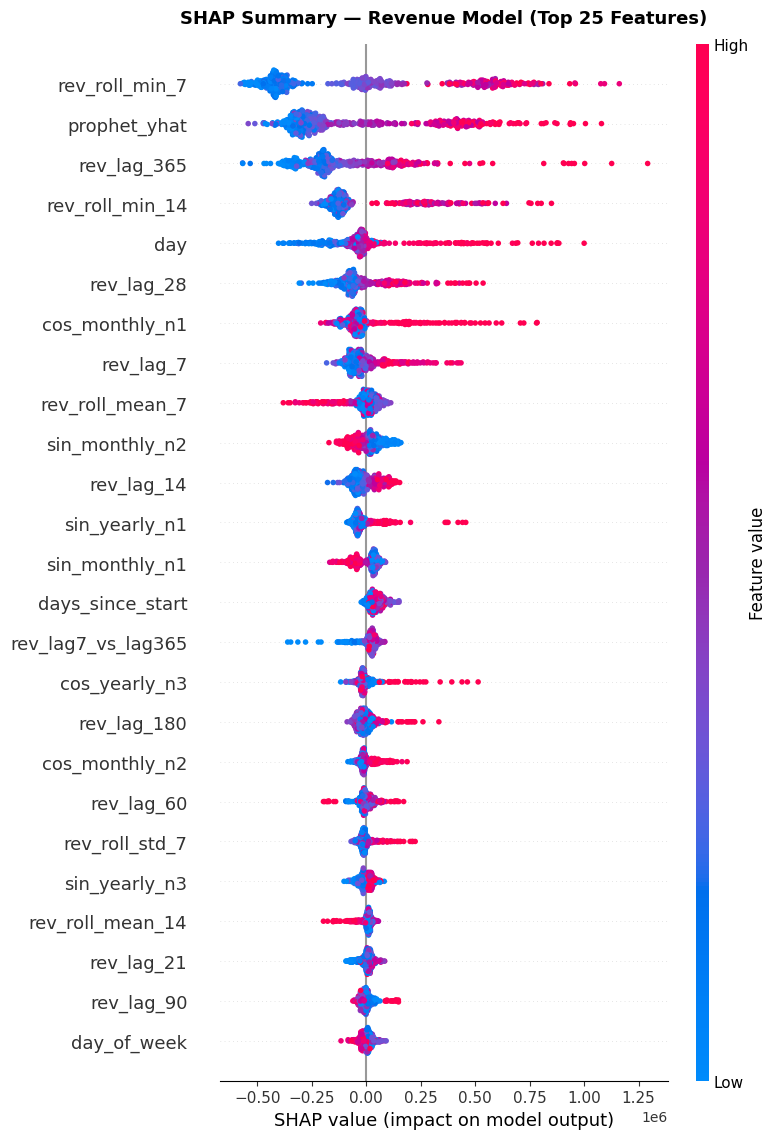

shap_summary_rev.png saved


In [4]:
plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values_rev, X_sample,
    plot_type='dot',
    max_display=25,
    show=False
)
plt.title('SHAP Summary — Revenue Model (Top 25 Features)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_summary_rev.png'), dpi=150, bbox_inches='tight')
plt.show()
print('shap_summary_rev.png saved')

## 4. SHAP Bar Plot — Revenue (Mean |SHAP|)

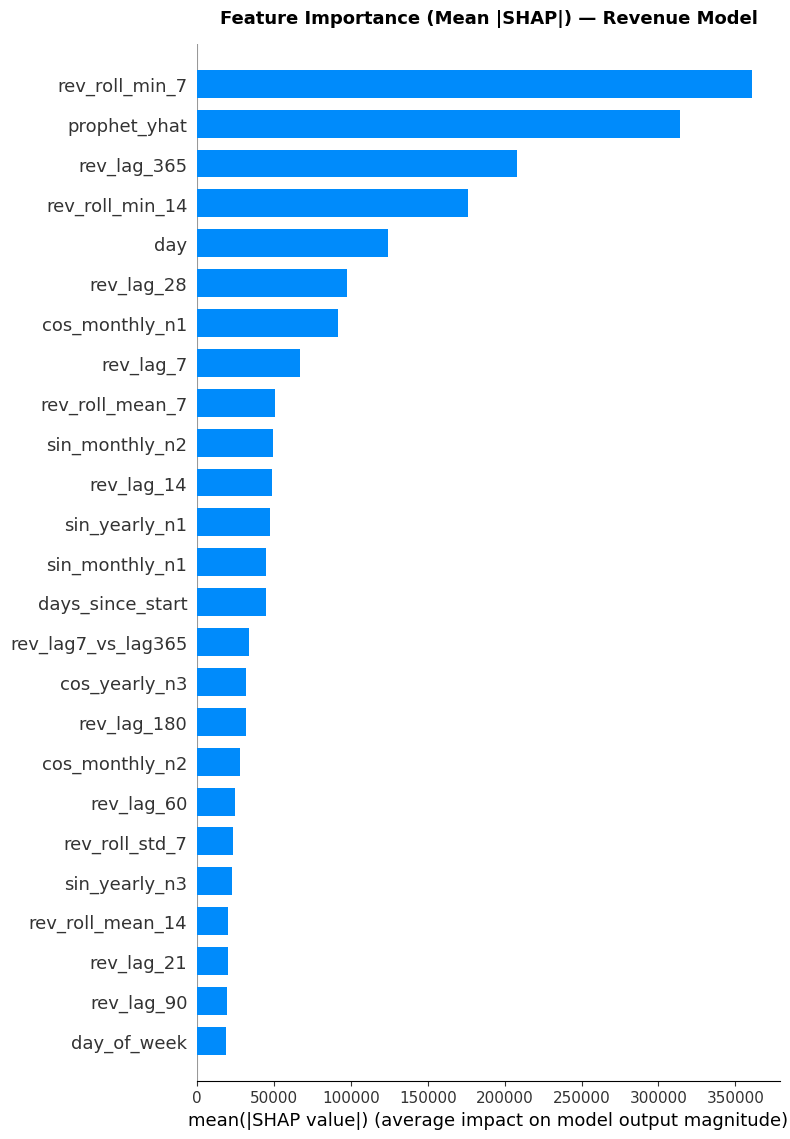

shap_bar_rev.png saved


In [5]:
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values_rev, X_sample,
    plot_type='bar',
    max_display=25,
    show=False
)
plt.title('Feature Importance (Mean |SHAP|) — Revenue Model', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_bar_rev.png'), dpi=150, bbox_inches='tight')
plt.show()
print('shap_bar_rev.png saved')

## 5. Feature Importance — Revenue Model

In [6]:
# Compute mean |SHAP| for Revenue model
mean_shap_rev = np.abs(shap_values_rev).mean(axis=0)
imp_rev = pd.DataFrame({'feature': FEATURE_COLS, 'mean_shap': mean_shap_rev})
imp_rev = imp_rev.sort_values('mean_shap', ascending=False).reset_index(drop=True)

# Save CSV
imp_rev.to_csv(os.path.join(OUTPUT_DIR, 'shap_importance_rev.csv'), index=False)

print('Top 15 Revenue Features (Mean |SHAP|):')
print(imp_rev.head(15).to_string(index=False))

Top 15 Revenue Features (Mean |SHAP|):
           feature     mean_shap
    rev_roll_min_7 361040.678506
      prophet_yhat 314202.159574
       rev_lag_365 207779.238013
   rev_roll_min_14 176390.180349
               day 124432.460182
        rev_lag_28  97336.336734
    cos_monthly_n1  91875.753108
         rev_lag_7  67237.047009
   rev_roll_mean_7  50713.492933
    sin_monthly_n2  49207.245960
        rev_lag_14  48450.105152
     sin_yearly_n1  47644.947607
    sin_monthly_n1  44718.335460
  days_since_start  44640.596660
rev_lag7_vs_lag365  33563.918372


## 6. SHAP Dependence Plots — Top Features

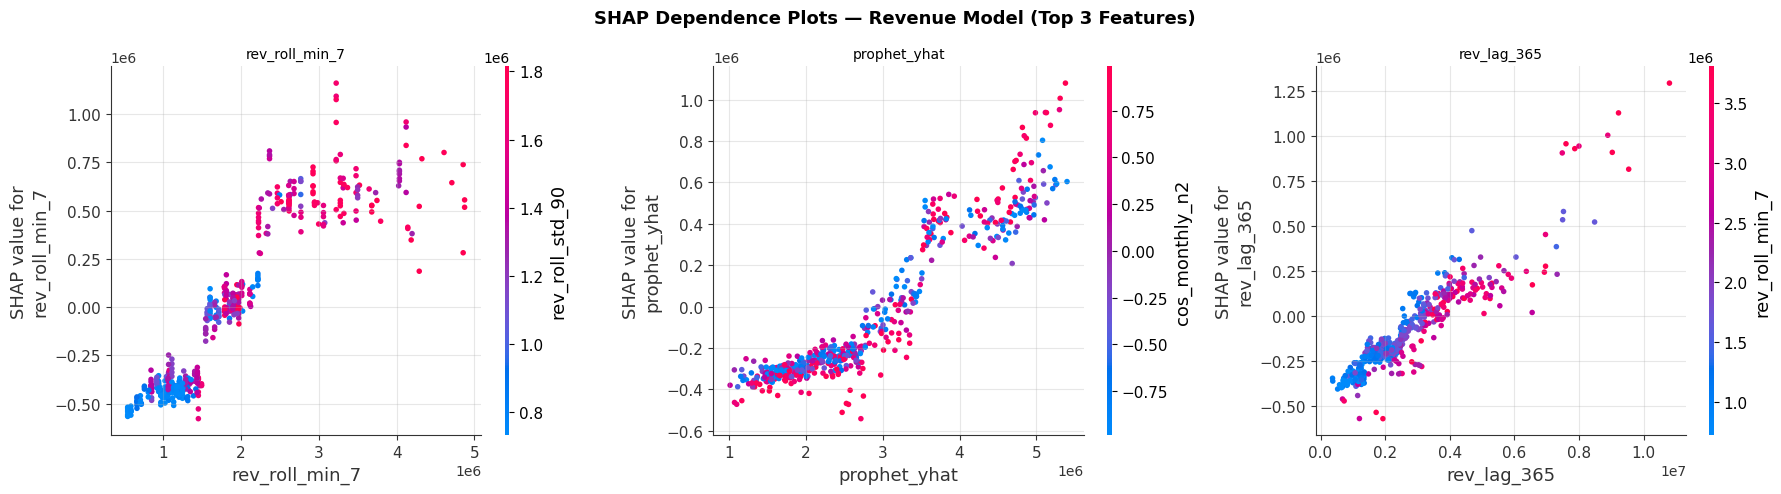

shap_dependence_rev.png saved


In [7]:
top3_rev = imp_rev.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Dependence Plots — Revenue Model (Top 3 Features)', fontsize=13, fontweight='bold')

for i, feat in enumerate(top3_rev):
    feat_idx = list(X_sample.columns).index(feat)
    shap.dependence_plot(
        feat, shap_values_rev, X_sample,
        ax=axes[i], show=False
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_dependence_rev.png'), dpi=150, bbox_inches='tight')
plt.show()
print('shap_dependence_rev.png saved')

## 7. Summary

In [8]:
print('=' * 65)
print('STAGE 5 COMPLETE — SHAP Explainability (Revenue Model)')
print('=' * 65)
print()
print('Outputs:')
print('  - shap_summary_rev.png      (dot plot, top 25 features)')
print('  - shap_bar_rev.png          (bar plot, mean |SHAP|)')
print('  - shap_dependence_rev.png   (dependence, top 3 features)')
print('  - shap_importance_rev.csv   (all features sorted by importance)')
print()
print('Top 5 Most Important Features:')
for i, row in imp_rev.head(5).iterrows():
    print(f'  {i+1}. {row["feature"]:30s} SHAP={row["mean_shap"]:12,.0f}')

STAGE 5 COMPLETE — SHAP Explainability (Revenue Model)

Outputs:
  - shap_summary_rev.png      (dot plot, top 25 features)
  - shap_bar_rev.png          (bar plot, mean |SHAP|)
  - shap_dependence_rev.png   (dependence, top 3 features)
  - shap_importance_rev.csv   (all features sorted by importance)

Top 5 Most Important Features:
  1. rev_roll_min_7                 SHAP=     361,041
  2. prophet_yhat                   SHAP=     314,202
  3. rev_lag_365                    SHAP=     207,779
  4. rev_roll_min_14                SHAP=     176,390
  5. day                            SHAP=     124,432


In [9]:
# (removed - COGS no longer part of pipeline)

In [10]:
# (removed)

In [11]:
# (removed)

In [12]:
# (removed)